# 数据科学/数据处理的通用框架流程

文件来源： 此文件出自Python For Beginner学习社群。

作者： 闫小峰

Last Update: 2025-04-15

## 数据处理通用框架/流程模板

[0. 业务理解 Understanding](#0) 

[1. 数据获取和理解 ](#1)
- 数据分析环境设置 Set Up Environment
- 数据获取/采样
- 数据探索  
  - 熟悉数据属性
  - 数据体检： Sanity Checking 

[2. 预处理 Data Preparation](#2)  
- 数据清理  Data Cleaning 
- 数据准备，转换和调整


[3. 数据分析和挖掘 Data Analysis / Data  Mining](#3)
- 传统（经典）数据分析： 
  - 统计学方法 
  - 建模： 业务分析模型
- 机器学习 Machine Learning: 
  - 模型构建: 训练-测试-调试， 
  - 模型预测
- AI增强/辅助型数据分析和开发
  - LLM

[4. 模型评估  Model Evaluation ](#4)


[5. 业务理解/知识深化和提升](#5)
- 数据处理流程自动化 Pipelines
- X by Data Based/Data Driven
   -  Decision Making
   -  Story Line
   -  逻辑论证
   -  发现规律 etc

# 0.业务理解Understanding

- 目标和需求分析：数据分析的背景，动机和目的：
  - 学习如何从大数据中挖掘信息和使用价值
      - 数据类型：金融数据
      - 来源：美国股市历史数据， 。。。
  - 学习金融领域的基本和底层模型，并学会使用金融模型结合结合经典统计学（和现代机器学习算法）进行分析
  - 学习提出自己的假设并利用上述知识进行验证
  - 将学习的金融知识融入到实战中，运用场景：资产配置
- 操作执行战术分析：数据分析需要的方法
  - 灵活使用numpy和pandas的数据结构进行数据处理和计算，并熟练掌握两者之间的互相转换
  - 学会调用函数（创建，导入自创库，Function Call）

### 1. 数据获取和理解 Get Data & Data Understanding <a id="1"></a>

### 1.1. 数据处理环境设置 Set Up Environment <a id="1.1"></a>

In [38]:
# import modules for data science 
import numpy as np
import pandas as pd

#import module for plotting
import matplotlib.pyplot as plt 

# import customer modules
import utils as myfin  

import warnings
warnings.filterwarnings('ignore') #to suppress warning messages

%load_ext autoreload
%autoreload 2
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1.2. 数据获取

### 1.2.1. 小测试样本数据

In [3]:
prices = pd.read_csv("data/sample_prices.csv")
prices 

,STOCK1,STOCK2
0,8.7000,10.6600
1,8.9055,11.0828
2,8.7113,10.7100
3,8.4346,11.5907
4,8.7254,12.1070
5,9.0551,11.7876
6,8.9514,11.2078
7,9.2439,12.5192
8,9.1276,13.3624
9,9.3976,14.4080


In [6]:
# calculate returns
returns = prices/prices.shift(1)-1 
returns

# print(prices.shift(1))


,STOCK1,STOCK2
0,NaN,NaN
1,0.023621,0.039662
2,-0.021807,-0.033638
3,-0.031763,0.082232
4,0.034477,0.044544
5,0.037786,-0.026381
6,-0.011452,-0.049187
7,0.032676,0.117008
8,-0.012581,0.067353
9,0.029581,0.078249


In [7]:
# calculate daily returns with alternative method
returns_alt = prices.pct_change()
returns_alt

,STOCK1,STOCK2
0,NaN,NaN
1,0.023621,0.039662
2,-0.021807,-0.033638
3,-0.031763,0.082232
4,0.034477,0.044544
5,0.037786,-0.026381
6,-0.011452,-0.049187
7,0.032676,0.117008
8,-0.012581,0.067353
9,0.029581,0.078249


In [8]:
returns_alt = returns_alt.dropna()
returns_alt

,STOCK1,STOCK2
1,0.023621,0.039662
2,-0.021807,-0.033638
3,-0.031763,0.082232
4,0.034477,0.044544
5,0.037786,-0.026381
6,-0.011452,-0.049187
7,0.032676,0.117008
8,-0.012581,0.067353
9,0.029581,0.078249
10,0.006151,-0.168261


In [10]:
returns_alt.mean()
display(returns_alt.std())

STOCK1    0.023977
STOCK2    0.079601
dtype: float64

<Axes: >

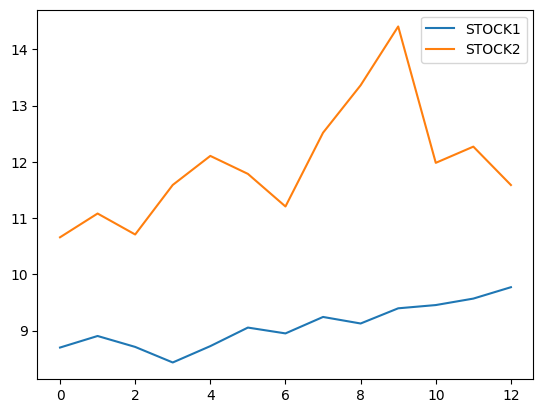

In [11]:
prices.plot()

### 1.2.2. 美国股市历史数据

来源：
- Kenneth French： https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/data_library.html#Research

#### Real US history data of 10 portfolios

Read in the monthly returns of a set of 10 portfolios formed on market caps, or market equities of the companies. we only want to look at the largest cap and the smallest cap companies:

In [3]:
# # input source data
me_m = pd.read_csv("data/Portfolios_Formed_on_ME.csv",
#                    header=7, index_col=0,skipfooter=1197, parse_dates=True, na_values=-99.99,engine='python') 
                     header=7, index_col=0, nrows=1192, parse_dates=True, na_values=-99.99,engine='python')# 
# me_m.shape
# #me_m.head()
me_m.tail()

,<= 0,Lo 30,Med 40,Hi 30,Lo 20,Qnt 2,Qnt 3,Qnt 4,Hi 20,Lo 10,2-Dec,3-Dec,4-Dec,5-Dec,6-Dec,7-Dec,8-Dec,9-Dec,Hi 10
202505,NaN,6.92,5.37,6.46,6.27,5.75,4.81,5.83,6.51,8.72,4.54,7.65,4.72,4.64,4.92,6.31,5.59,6.17,6.56
202506,NaN,6.05,4.22,5.25,6.77,6.03,4.28,3.85,5.32,6.11,7.24,5.27,6.46,4.49,4.14,3.26,4.15,3.88,5.51
202507,NaN,2.06,1.74,2.37,1.82,1.53,1.71,1.80,2.41,2.34,1.47,2.32,1.02,1.66,1.75,2.03,1.68,1.90,2.47
202508,NaN,9.18,5.21,1.92,9.32,8.61,5.96,3.34,1.83,8.28,10.03,9.04,8.34,5.67,6.18,3.23,3.41,1.52,1.87
202509,NaN,2.19,0.61,3.98,3.42,0.93,0.94,0.19,4.19,5.18,2.23,0.87,0.97,1.28,0.69,0.07,0.25,1.03,4.58


In [4]:
# select only small cap and large cap portfolios
returns = me_m[['Lo 10','Hi 10']]
returns.head()

,Lo 10,Hi 10
192607,-0.62,3.67
192608,1.65,3.79
192609,0.57,1.26
192610,-4.29,-2.56
192611,-3.18,2.45


#### IND30 Ken French Dataset

The Ken French dataset contains the returns of 30 different industry portfolios.

In [55]:
ind = myfin.get_ind_returns()
ind.tail()
#er = myfin.annualize_rets(ind["1996":"2000"], 12)
#cov = ind["1996":"2000"].cov()

,Food,Beer,Smoke,Games,Books,Hshld,Clths,Hlth,Chems,Txtls,...,Telcm,Servs,BusEq,Paper,Trans,Whlsl,Rtail,Meals,Fin,Other
2025-05,-0.0047,-0.0344,0.0462,0.0649,0.0430,0.0410,0.1027,-0.0396,0.0233,-0.0271,...,0.0386,0.1110,0.0928,0.0453,0.0727,0.0238,0.0647,0.0368,0.0430,0.0123
2025-06,-0.0067,-0.0167,0.0075,0.1010,0.0356,-0.0391,0.0201,0.0201,0.0034,0.0459,...,0.0363,0.0645,0.1079,-0.0212,0.0475,0.0155,0.0275,0.0196,0.0551,-0.0102
2025-07,-0.0226,0.0338,-0.0584,-0.0831,-0.0334,-0.0310,0.0251,-0.0127,-0.0067,0.0095,...,-0.0336,0.0445,0.0612,-0.0138,-0.0206,0.0014,0.0311,-0.0251,-0.0068,-0.0254
2025-08,0.0185,0.0349,0.0387,0.0508,0.0582,0.0327,0.0425,0.0474,0.0634,0.1747,...,0.0380,-0.0106,0.0339,0.0402,0.0421,0.0154,0.0085,0.0088,0.0418,0.0443
2025-09,-0.0221,-0.0712,-0.0209,-0.0175,0.0086,-0.0354,-0.0542,0.0203,-0.0463,-0.0335,...,-0.0113,0.0479,0.0813,-0.0391,0.0049,0.0080,-0.0106,-0.0461,0.0117,-0.0007


# 2. 数据预处理 Data Preparation  <a id="2"></a>

## 2.1.1 US Market Monthly Portfolio Data Preparation

In [5]:
# convert percentage to decimal
returns = returns.apply(lambda s: pd.to_numeric(s, errors='coerce'))
returns.dtypes
returns = returns/100
returns.head()

,Lo 10,Hi 10
192607,-0.0062,0.0367
192608,0.0165,0.0379
192609,0.0057,0.0126
192610,-0.0429,-0.0256
192611,-0.0318,0.0245


<Axes: >

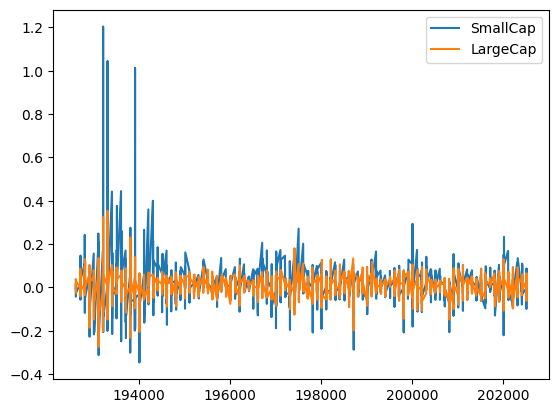

In [6]:
returns.columns = ['SmallCap','LargeCap']
returns.plot()

In [7]:
# 处理数据集中的时间戳
returns.index 
returns.index = pd.to_datetime(returns.index, format='%Y%m')
returns.index


DatetimeIndex(['1926-07-01', '1926-08-01', '1926-09-01', '1926-10-01',
               '1926-11-01', '1926-12-01', '1927-01-01', '1927-02-01',
               '1927-03-01', '1927-04-01',
               ...
               '2024-12-01', '2025-01-01', '2025-02-01', '2025-03-01',
               '2025-04-01', '2025-05-01', '2025-06-01', '2025-07-01',
               '2025-08-01', '2025-09-01'],
              dtype='datetime64[ns]', length=1191, freq=None)

In [8]:
# Monthly data is an index that is date stamped. Fix this using the `to_period` method
returns.index = returns.index.to_period('M')
returns.index

PeriodIndex(['1926-07', '1926-08', '1926-09', '1926-10', '1926-11', '1926-12',
             '1927-01', '1927-02', '1927-03', '1927-04',
             ...
             '2024-12', '2025-01', '2025-02', '2025-03', '2025-04', '2025-05',
             '2025-06', '2025-07', '2025-08', '2025-09'],
            dtype='period[M]', length=1191)

✅我们可以把上述成功测试好的数据读取和初步处理流程固定下来，构建成一个自己的函数，放入自建库中备用

In [9]:
#数据处理好了以后可以任意使用了，比如取某一年的数据
returns["SmallCap"]['2023']

2023-01    0.1143
2023-02   -0.0412
2023-03   -0.0605
2023-04   -0.0132
2023-05   -0.0017
2023-06    0.0435
2023-07    0.0679
2023-08   -0.0833
2023-09   -0.0618
2023-10   -0.0769
2023-11    0.0594
2023-12    0.1349
Freq: M, Name: SmallCap, dtype: float64

# 3. 数据分析和探索，建模  Data Analysis & Data  Mining，Modelling <a id="3"></a>

## 3.1. 金融分析基础概念和模型

## 如何评估收益

基本收益指标：直观，简单好理解。

### 收益率（Returns）

return from time $t$ to time ${t+1} is given by:

$$ R_{t,t+1} = \frac{P_{t+1}-P_{t}}{P_{t}} $$

or alternately

$$ R_{t,t+1} = \frac{P_{t+1}}{P_{t}} - 1 $$


计算累计收益率时:
- 基于“复利式”计算方法：乘法因子 "1+R" format
- 回算收益率时需要做 -1 转换


In [19]:
# If you come from R or another language that supports vectors, you might expect something like this to work:

prices_a = np.array([10, 12, 14, 13, 15])
returns_a = prices_a[1:]/prices_a[:-1] - 1
returns_a

array([ 0.2       ,  0.16666667, -0.07142857,  0.15384615])

### 年化收益率（Annualizing Returns）

To annualize a return for a period, you compound the return for as many times as there are periods in a year. For instance, to annualize a monthly return you compund that return 12 times. The formula to annualize a monthly return $R_m$ is:

$$ (1+R_m)^{12} - 1$$

To annualize a quarterly return $R_q$ you would get:

$$ (1+R_q)^{4} - 1$$

And finally, to annualize a daily return $R_d$ you would get:

$$ (1+R_d)^{252} - 1$$

年化收益率的计算公式是**（投资内收益/本金/投资天数）×365×100%**。

对于复利投资，可以使用公式年化收益率 = (期末资产净值 / 期初资产净值)^365/投资天数- 1来计算。 
方法一：按天数计算（适用于非复利） 
•	公式：年化收益率 = (投资收益 / 本金 / 投资天数) × 365 × 100%
•	举例：
o	本金是10000元
o	投资了180天
o	获得了收益200元
o	年化收益率 = (200/10000/180) × 365 × 100% ≈ 4.06% 
方法二：复利计算 
•	公式：年化收益率 = (期末资产净值 / 期初资产净值)^(365/投资天)- 1
 
补充说明 
- 年化收益率是把当前收益率（日收益率、周收益率、月收益率）换算成年收益率来计算的，是一种**理论收益率**，并不是真正的已取得的收益率。
作用：提供一个可用衡量对比的基准
- 注意定义的模糊性： 有效时间的不同规定：一年的有效投资时间，对银行存款、票据、债券等D=360日，对于股票、期货等市场D=250日，对于房地产和实业等D=365日
- 在实际投资中，年化收益率会受市场波动等多种因素影响，可能与实际收益率不同。
- 对于货币基金、债券等有固定收益或定期调整收益的投资，实际收益率可能更接近年化收益率。 



## 如何评估风险

## 波动率（Volatility）

volatility is measured by the average squared deviation from the mean = standard deviation.

波动率是衡量金融资产价格在特定期间内波动程度的指标，通常以百分比或点数表示。它反映市场的活跃程度：波动率高代表价格剧烈波动，波动率低则表示价格相对稳定。


### Drawdown (The maximum drawdown)=max. loss回撤

回撤（或最大回撤）是另外一个（更真实）反应风险的评估指标。

Drawdowns计算算法：

1. Convert the time series of returns to a time series that represents a wealth index
2. Compute a time series of the previous peaks
3. Compute the Drawdown as the difference between the previous peak and the current value

### 半标准差 (Semideviation)

又称为半偏差或下偏标准差 (Downside Deviation)，是统计学和金融学中衡量风险的一种指标，主要关注投资回报低于特定目标值（通常是平均回报率或最低可接受回报率）时的波动性。 

核心概念
与传统的标准差（Standard Deviation）衡量数据围绕均值的双向波动不同，半标准差仅计算低于均值或预设目标的那些观测值的离散程度。其核心思想在于：对于投资者而言，高于预期的正收益通常不被视为“风险”，真正的风险在于收益低于预期或出现亏损。 

主要特点与用途
- 风险的不对称性：半标准差捕捉了金融市场中风险的不对称性，即人们更关心损失而非意外收益。
- 关注下行风险：它是一种专门度量“下行风险”（Downside Risk）的指标。


### 风险价值(Value at Risk)

风险价值(VaR)是一种统计度量，用于在**特定的时间范围**和给定的**置信度**水平上估计投资或投资组合的潜在损失。它提供了一种量化投资的下行风险的方法，并帮助投资者在风险管理和投资组合分配方面做出明智的决策。

VaR通常以负的金额表示，代表投资者在一定程度的信心下可以预期经历的最大损失。

## 从简单到晋级：如何在整体金融市场中评估收益

需要一下基本假设和基础模型。

### CAPM（资本资产定价模型）

CAPM（资本资产定价模型）是现代金融学最重要的模型，可以用来：计算资产的系统风险，估计资产的预期收益率，评价投资组合的业绩。 该模型在诺奖得主哈里·马科维茨（Harry Markowitz）的投资组合理论（又称均值方差理论）基础之上产生，由威廉·夏普（William Sharpe）正式提出

资本资产定价模型（CAPM）是现代金融理论中的一个基本概念，用于通过考虑投资相对于整体市场的内在风险来确定投资的预期回报率。 该模型提供了一种结构化的方法来评估风险和回报之间的权衡，这对于做出明智的投资决策来说是至关重要的。 资本资产定价模型中包含了三个主要的组成部分：无风险利率、β 系数和市场风险溢价

计算公式：
𝐸(𝑅𝑖)=𝑅𝑓+𝛽𝑖(𝐸(𝑅𝑚)−𝑅𝑓)

公式说明：
- 𝐸(𝑅𝑖)代表资产的预期收益率。
- 𝑅𝑓代表无风险利率。
- 𝛽𝑖代表资产的Beta值，衡量资产相对于市场波动的敏感度。
- 𝐸(𝑅𝑚)代表市场的平均预期收益率。
- (𝐸(𝑅𝑚)−𝑅𝑓)代表市场风险溢价。



夏普比率（Sharpe Ratio）

夏普比率是衡量投资效率的重要指标，它通过比较投资的超额回报与承担的风险来评估投资性价比。

计算公式为投资的超额收益（投资回报率减去无风险利率）除以投资的标准差（风险）： 


- 衡量投资效率： 它衡量的是在承担单位风险的情况下，能够获得的超额回报。 夏普比率越高，表明投资在承受单位风险下所获得的回报越高
- 比较不同投资： 夏普比率可以用来比较风险水平不同的金融产品，帮助判断哪种产品更具效率。

### 3.1.1. Data Analysis on Simple Prices Data

In [ ]:
returns = returns.dropna()
deviations = returns - returns.mean()
# deviations 
sq_deviations = deviations **2
#sq_deviations
meann_sq_dev = sq_deviations.mean()
# numpy
# volatility =  np.sqrt(meann_sq_dev)
#pandas
returns.std() 
volatility

NameError: name 'volatility' is not defined

### 3.1.2. Data Analysis on Portfolio Monthly Data

In [10]:
# calculate the annualized returns
n_month= returns.shape[0]
annualized_returns = ((1 + returns).prod())**(12/n_month) - 1
annualized_returns

SmallCap    0.119910
LargeCap    0.100147
dtype: float64

In [11]:
# calculate the annualized volatility
month_to_year = 12  # monthly data
annualized_volatility = returns.std() * np.sqrt(month_to_year)
annualized_volatility

SmallCap    0.337115
LargeCap    0.174067
dtype: float64

<Axes: >

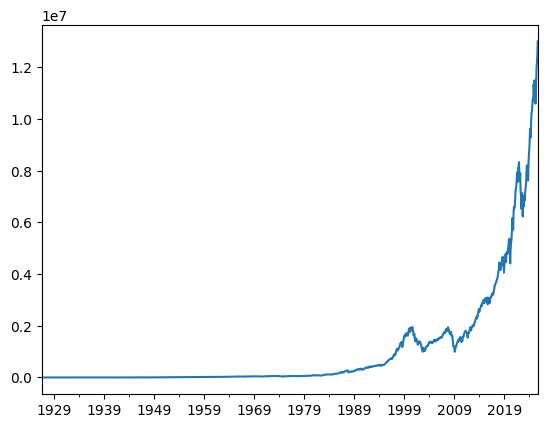

In [12]:
# 风险评估方法：计算（最大）回撤
wealth_index = 1000*(1+returns["LargeCap"]).cumprod()
wealth_index.plot()



<Axes: >

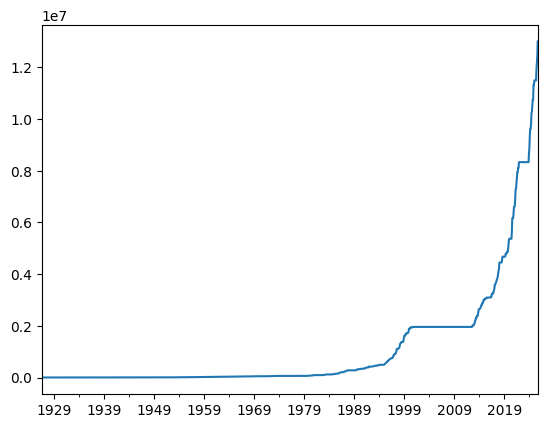

In [13]:
previous_peaks = wealth_index.cummax()
previous_peaks.plot()

<Axes: >

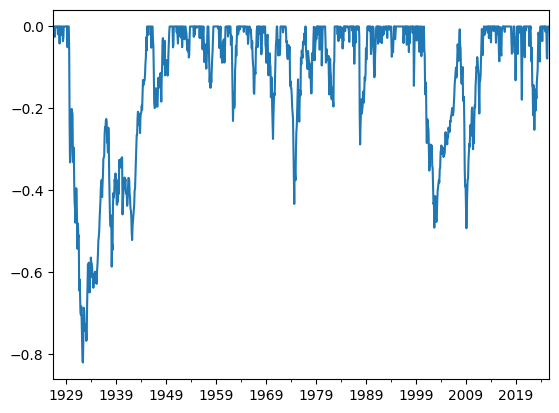

In [14]:
drawdown = (wealth_index - previous_peaks)/previous_peaks
drawdown.plot()

In [15]:
# find the max. drawdown
max_drawdown = drawdown.min()   
max_drawdown

np.float64(-0.8204179705764917)

<Axes: >

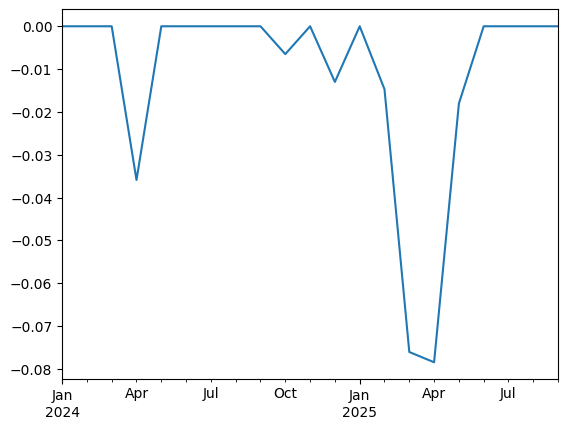

In [16]:
# look for drawndown in any period
drawdown["2025"].min()
drawdown["2024":].plot()

<Axes: >

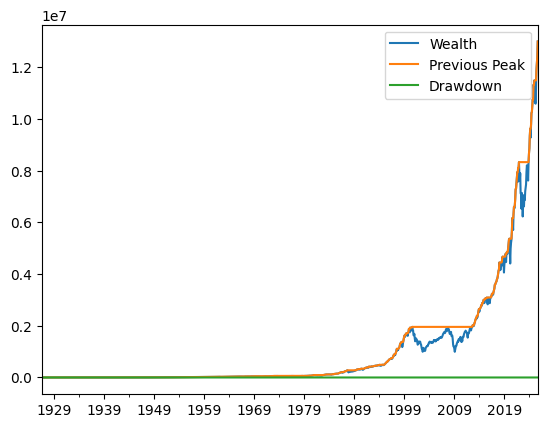

In [17]:
# use user-defined function
#import utils as myfin
myfin.drawdown(returns["LargeCap"]).plot()

In [18]:
myfin.drawdown(returns["LargeCap"]["2024"]).min()

Wealth           1024.2000
Previous Peak    1024.2000
Drawdown           -0.0359
dtype: float64

In [19]:
# find the historic max. drowndown
myfin.drawdown(returns["LargeCap"])["Drawdown"]['2024'].idxmin()

Period('2024-04', 'M')

In [20]:
# calculate the semideviation
myfin.semideviation(returns)

SmallCap    0.054291
LargeCap    0.037255
dtype: float64

In [21]:
# calculate the VaR at 5% level using the historical meth
myfin.var_historic(returns["SmallCap"], level=5)

np.float64(0.11099999999999999)

我们可以使用这些风险概念（关键点：是可量化的指标）来分析和思考我们的投资选择和组合，然后做出合理的决策。

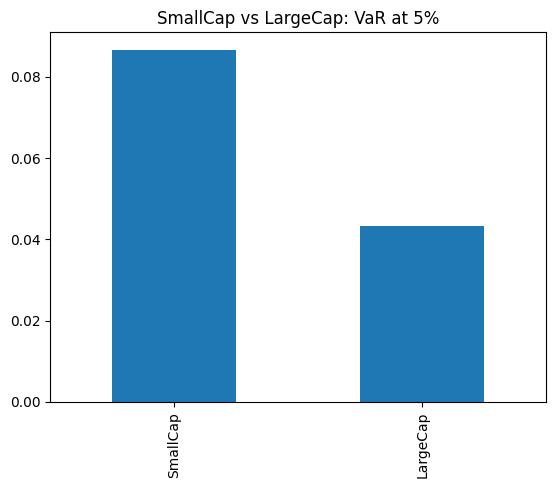

In [31]:
var_small = myfin.var_historic(returns["SmallCap"]["2025"], level=5) 
var_large = myfin.var_historic(returns["LargeCap"]["2025"], level=5)
# print(type(var_small), type(var_large))

# If both are scalars -> create a Series for plotting
if isinstance(var_small, (int, float, np.floating)) and isinstance(var_large, (int, float, np.floating)):
    s = pd.Series({"SmallCap": float(var_small), "LargeCap": float(var_large)})
    s.plot.bar(title="SmallCap vs LargeCap: VaR at 5%")
else:
    # Ensure both are Series/DataFrame and align by index before concat
    s_small = pd.Series(var_small, name="SmallCap") if not isinstance(var_small, (pd.Series, pd.DataFrame)) else (var_small.rename("SmallCap") if isinstance(var_small, pd.Series) else var_small)
    s_large = pd.Series(var_large, name="LargeCap") if not isinstance(var_large, (pd.Series, pd.DataFrame)) else (var_large.rename("LargeCap") if isinstance(var_large, pd.Series) else var_large)
    comparison = pd.concat([s_small, s_large], axis=1)
    comparison.plot.bar(title="SmallCap vs LargeCap: VaR at 5%")

有了基本的收益和风险概念，进一步思考：
- 有没有一种投资可以“只赚不赔”？
- 有没有一种资产呈现出比其他资产更安全收益更高的特征？
  
本质上讲，就是要寻找一个指标可以衡量风险条件下的收益程度/高低。人们会自然想到比值法。

这里还需引入一个概念：无风险收益率。

最后的结果就是：`夏普比率`.

In [93]:
annualized_returns/annualized_volatility

SmallCap    0.355694
LargeCap    0.575336
dtype: float64

In [ ]:
riskfree_rate = 0.04
excess_returns = annualized_returns - riskfree_rate
sharpe_ratio = excess_returns/annualized_volatility
sharpe_ratio

SmallCap    0.266704
LargeCap    0.402989
dtype: float64

### 3.1.3. Data Analysis on US Industry Monthly Data

In [46]:
ind.columns
ind.shape

(1191, 30)

In [48]:
# check returns
a_rets = myfin.annualize_rets(ind["2000":"2025"], 12)

<Axes: >

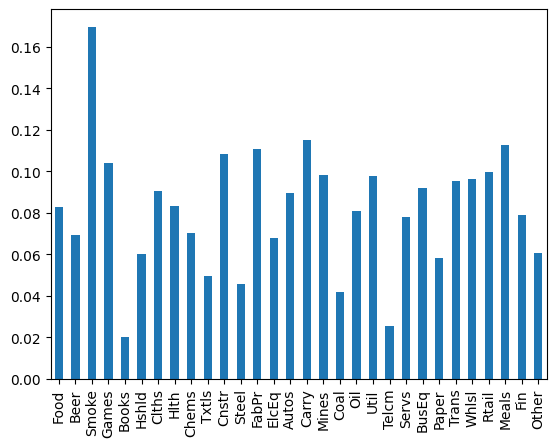

In [49]:
#plot the data 
a_rets.plot.bar()

<Axes: >

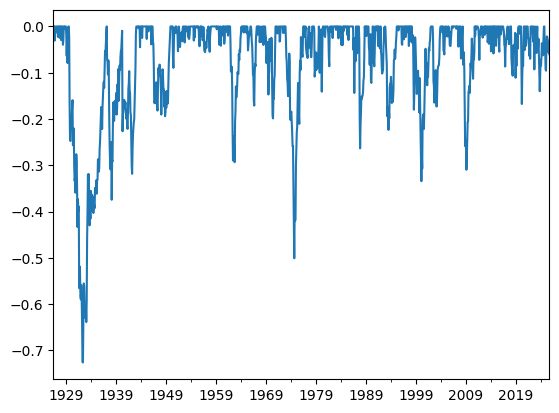

In [47]:
# look for drawdown for selected sectors
myfin.drawdown(ind["Food"])["Drawdown"].plot.line()

We check the sharpe ratio for the total market

In [51]:
myfin.sharpe_ratio(ind, 0.03, 12).sort_values()

Coal     0.086381
Steel    0.144133
Txtls    0.166273
Whlsl    0.177600
Other    0.193189
Books    0.193233
Games    0.200908
Trans    0.215870
Mines    0.217605
Clths    0.255201
Autos    0.256662
Cnstr    0.268948
Servs    0.269727
Fin      0.285454
Carry    0.290197
FabPr    0.292059
ElcEq    0.295277
Hshld    0.301164
Oil      0.319380
Chems    0.319903
Util     0.320867
Beer     0.334761
Paper    0.336431
Meals    0.337417
Telcm    0.360810
Rtail    0.385904
BusEq    0.396683
Hlth     0.431635
Food     0.443253
Smoke    0.461599
dtype: float64

<Axes: >

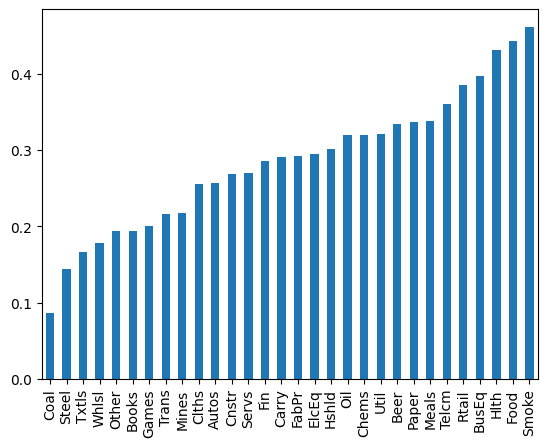

In [53]:
# visualization of the sharpe ratio over periods
myfin.sharpe_ratio(ind["1926":"2025"], 0.03, 12).sort_values().plot.bar()

<Axes: title={'center': 'Industry Sharpe Ratios since 2000'}>

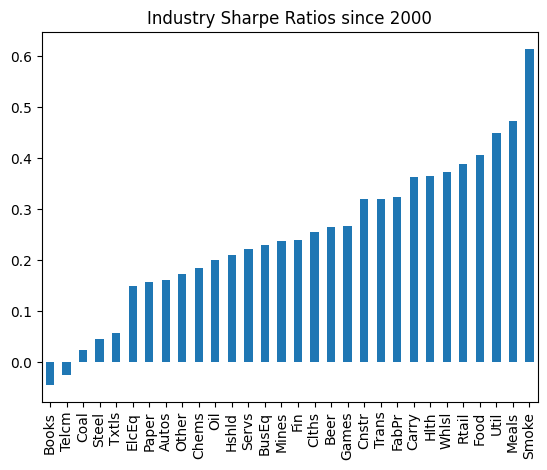

In [54]:
myfin.sharpe_ratio(ind["2000":], 0.03, 12).sort_values().plot.bar(title='Industry Sharpe Ratios since 2000')

let's generate the covariance matrix. Fortunately, this is easy enough to do using the `.cov` method:

In [50]:
cov = ind["1995":"2025"].cov()
cov.shape

(30, 30)

## 4. 模型评估 Model Evaluation <a id="4"></a> 

## 5. 业务理解/知识深化和提升  <a id="5"></a> 